# ***Portuguese Bank Marketing - Term Deposit Subscription Analysis***

Dev Sharma

## 1. Introduction

**Bank Marketing Dataset: https://archive.ics.uci.edu/dataset/222/bank+marketing**


**Dataset Introduction:** This dataset from the UC Irvine Machine Learning Repository consolidates the user profiles of various clients that a Portuguese bank targets through their direct marketing campaigns, which are conducted over the phone. In each user profile, clients have data on their personal life, financial background, and history with the company's marketing campaigns. For personal data, each client's age, job, marital status, and education is recorded. For financial background, each client is assessed for whether they have credit in default, a housing loan, a personal loan and what their average yearly balance is. As for each client's history with the company's campaigns, The bank intends to use all of these characteristics to predict whether a client would subscribe to their term deposit.

**Research Question 1:** What is the relationship between whether a client has a housing loan (indicated by variable *housing*) and their age after holding their education, marital status, and the duration of the last time they were contacted constant, both in the sample and in the underlying population? How does the model perform on new data? ***The response variable in this question is age.***

**Q1 Contextual Importance:** The contextual importance of this research question would be relevant to banks and clients who would want to know if age could predict if a person needs a housing loan so that they would be able to target advertising to those specific age groups, including those who are undergraduate and post-graduate students.

**Research Question 2:** How does the outcome of the previous marketing campaign (poutcome) with a client, their job (grouped_jobs), and the number of times the client has been contacted before this campaign (previous) relate to the log-odds of the success level of whether the client has subscribed to the bank's term deposit (subscribed) during the current campaign in the sample training data? How does a classifier built on this model perform on new data? ***The response variable in this question is the logical variable "subscribed," which represents whether or not an individual has subscribed to the Portuguese bank's term deposit.***

**Q2 Contextual Importance:** The contextual importance of this research queston is relevant to banks and clients who would want to know the relationship between a person's impact from the advertisements, the type of job they have, and the number of times the client was contacted before the marketing campaign and the log odds (or linear measure of odds) of them subscribing to a bank. Banks would be able to use this information to predict how likely it is for a client to subscribe to the bank based on the impact of their marketing campaign on a potential or current client.

In [ ]:
#Imports here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf

In [2]:
import pandas as pd
df = pd.read_csv("bank-marketing-data.csv", na_values = ["unknown"])
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,149,1,999,0,nonexistent,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,yes


In [3]:
df.poutcome.unique()

array(['nonexistent', 'failure', 'success'], dtype=object)

In [4]:
df.isna().sum()

age               0
job             330
marital          80
education      1731
default        8597
housing         990
loan            990
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
subscribed        0
dtype: int64

In [5]:
df = df.dropna()
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,yes


In [6]:
def group_job(row):
    if ((row.job == "admin.") | (row.job == "management") | (row.job == "entrepreneur") | (row.job == "self-employed")):
        return "white-collar"
    elif((row.job == "blue-collar") | (row.job == "technician") | (row.job == "services") | (row.job == "housemaid")):
        return "blue-collar"
    elif((row.job == "retired") | (row.job == "unemployed") | (row.job == "student")):
        return "non-working"
    else:
        return "unknown"

def convert_to_int(row):
    if(row["subscribed"] == "yes"):
        return 1
    else:
        return 0

df["grouped_jobs"] = df.apply(group_job, axis = 1)
df["subscribed"] = df.apply(convert_to_int, axis = 1)
df


/var/folders/hr/v66rr5pj57vd6rwdy4ffnl7r0000gn/T/ipykernel_42516/2084505220.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["grouped_jobs"] = df.apply(group_job, axis = 1)
/var/folders/hr/v66rr5pj57vd6rwdy4ffnl7r0000gn/T/ipykernel_42516/2084505220.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["subscribed"] = df.apply(convert_to_int, axis = 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,subscribed,grouped_jobs
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,0,blue-collar
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,0,blue-collar
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,0,white-collar
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,0,blue-collar
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,0,white-collar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,1,non-working
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,0,blue-collar
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,0,non-working
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,1,blue-collar


Here I am grouping the options in the job variable to 4 main groups, mainly 'blue-collar', 'white-collar', 'non-working', and 'unknown'. This allows for easier analysis when making the logistic model later, as there are less options to add in the equation. I converted the 'subscribed' variable to a logical-variable that stores a prediction of whether each client would subscribe to their term deposit for the Portugese Bank using "1's" and "0's" to make predictions of this response variable in the logistic regression model.

## 2. Linear Regression Analytical Tasks

### **Research Question 1:**

What is the relationship between whether a client has a housing loan (indicated by variable *housing*) and their age after controlling for their education, marital status, and the duration of the last time they were contacted constant, both in the sample and in the underlying population? How does my model perform on new data?


### **Splitting into Test & Training Datasets:**

In [7]:
df_train, df_test = train_test_split(df, test_size = 0.2, random_state = 1000)

In [8]:
df_train

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,subscribed,grouped_jobs
22595,48,technician,married,university.degree,no,no,no,cellular,aug,fri,209,1,999,0,nonexistent,0,blue-collar
14858,55,housemaid,married,university.degree,no,yes,no,cellular,jul,wed,705,1,999,0,nonexistent,0,blue-collar
11888,28,admin.,single,high.school,no,no,no,telephone,jun,fri,22,16,999,0,nonexistent,0,white-collar
6972,38,technician,married,basic.9y,no,no,no,telephone,may,thu,514,3,999,0,nonexistent,0,blue-collar
1353,20,entrepreneur,single,high.school,no,no,no,telephone,may,thu,238,1,999,0,nonexistent,0,white-collar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23300,45,technician,single,professional.course,no,yes,no,cellular,aug,wed,105,1,999,0,nonexistent,0,blue-collar
5978,42,services,married,professional.course,no,yes,no,telephone,may,tue,1205,1,999,0,nonexistent,1,blue-collar
9794,39,management,married,university.degree,no,no,no,telephone,jun,wed,129,3,999,0,nonexistent,0,white-collar
7387,25,blue-collar,married,basic.6y,no,no,no,telephone,may,fri,25,4,999,0,nonexistent,0,blue-collar


In [9]:
df_test

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,subscribed,grouped_jobs
6043,41,blue-collar,married,basic.9y,no,no,no,telephone,may,tue,73,2,999,0,nonexistent,0,blue-collar
9513,41,blue-collar,married,basic.9y,no,yes,no,telephone,jun,mon,157,2,999,0,nonexistent,0,blue-collar
4707,32,blue-collar,married,basic.9y,no,no,no,telephone,may,wed,490,1,999,0,nonexistent,0,blue-collar
40586,60,retired,married,university.degree,no,no,no,cellular,sep,thu,529,2,6,1,success,1,non-working
39430,58,housemaid,single,professional.course,no,no,no,cellular,apr,mon,158,2,6,2,success,0,blue-collar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36618,35,admin.,married,university.degree,no,no,no,cellular,jun,thu,121,4,999,0,nonexistent,1,white-collar
38984,80,retired,divorced,basic.4y,no,no,yes,cellular,dec,fri,720,5,999,1,failure,0,non-working
25007,53,admin.,divorced,university.degree,no,yes,no,cellular,nov,tue,69,1,999,0,nonexistent,0,white-collar
32680,51,entrepreneur,divorced,university.degree,no,yes,no,cellular,may,mon,212,1,999,0,nonexistent,0,white-collar


### **Fitting Linear Regression Model to Training Data:**

In [10]:
linear_results = smf.ols("age ~ housing + education + marital + duration", data = df_train).fit()
linear_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    age   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     683.4
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        16:57:03   Log-Likelihood:                -88444.
No. Observations:               24390   AIC:                         1.769e+05
Df Residuals:                   24379   BIC:                         1.770e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           50.8673      0.275    185.181      0.000      50.329      51.406
housing[T.yes]                       0.3099      0.117      2.652      0.008       0.081       0.539
education[T.basic.6y]               -7.2768      0.345    -21.084      0.000      -7.953      -6.600
education[T.basic.9y]               -8.2779      0.260    -31.838      0.000      -8.788      -7.768
education[T.high.school]            -8.2124      0.240    -34.195      0.000      -8.683      -7.742
education[T.illiterate]             -4.1842      3.038     -1.377      0.168     -10.140       1.771
education[T.professional.course]    -6.9518      0.260    -26.703      0.000      -7.462      -6.442
education[T.university.degree]      -7.1325      0.233    -30.615      0.000      -7.589      -6.676
marital[T.married]                  -2.9328      0.187    -15.673      0.000      -3.300      -2.566
marital[T.single]                  -11.1397      0.201    -55.544      0.000     -11.533     -10.747
duration                             0.0004      0.000      1.811      0.070   -3.29e-05       0.001
==============================================================================
Omnibus:                     2887.853   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4541.054
Skew:                           0.849   Prob(JB):                         0.00
Kurtosis:                       4.258   Cond. No.                     1.93e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.93e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### *Linear Regression Equation*

**Predicted_Mean_Age = 50.8673 + 0.3099(housing[T.yes]) - 7.2768(education[T.basic.6y]) - 8.2779(education[T.basic.9y]) - 8.2124(education[T.high.school]) - 4.1842(education[T.illiterate]) - 6.9518(education[T.professional.course]) - 7.1325(education[T.university.degree]) - 2.9328(marital[T.married]) - 11.1397(marital[T.single]) + 0.0004(duration)**

### **Examining Relationship:**

**Interpreting the Slope of housing[T.yes]**

A client with a housing loan has a predicted mean age that is 0.3099 years higher than the predicted mean age of a client without a housing loan, holding education[T.basic.6y], education[T.basic.9y], education[T.high.school], education[T.illiterate], education[T.professional.course], education[T.university.degree], marital[T.married], marital[T.single], and duration constant.

This shows that there is a positive relationship between a client's age and whether or not they have a housing loan.

### **Performing Inference for Slope in Underlying Population**

#### *Simulation*

In [11]:
def sampling_distribution(reps = 500, data = df_train, sample_size = 24390, var = "housing[T.yes]", with_replace = True):
    sample_slopes = []
    for i in range(reps):
        sample = data.sample(sample_size, replace = with_replace)
        results = smf.ols("age ~ housing + education + marital + duration", data = sample).fit()
        sample_coef = results.params[var]
        sample_slopes.append(sample_coef)
    df = pd.DataFrame({"Sample Slopes for Client Age": sample_slopes})
    return df

sampling_distr = sampling_distribution()
sampling_distr

,Sample Slopes for Client Age
0,0.280061
1,0.402138
2,0.310411
3,0.403954
4,0.275711
...,...
495,0.310950
496,0.394315
497,0.343893
498,0.166525


In [30]:
sampling_distr["Sample Slopes for Client Age"].quantile(0.025)

np.float64(0.07964459566919853)

In [31]:
sampling_distr["Sample Slopes for Client Age"].quantile(0.975)

np.float64(0.5543437019487246)

#### ***95% Confidence Interval: [0.07964459566919853, 0.5543437019487246]***
I am 95% confident that the true population slope for the age of a client is between 0.07964459566919853 and 0.5543437019487246.

#### *Checking Linear Regression Conditions*

**Normality**

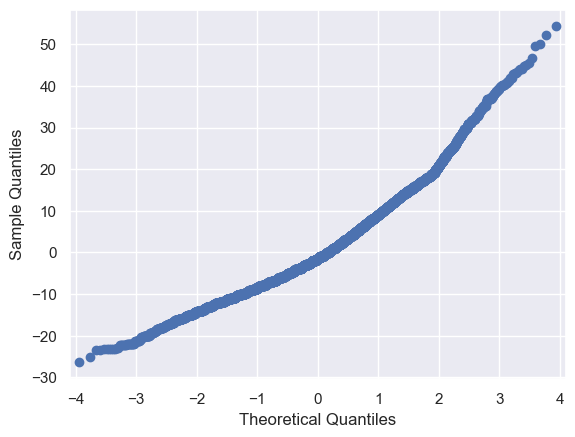

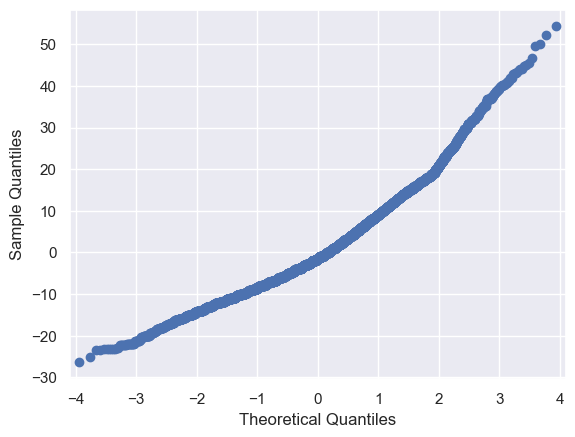

In [15]:
import statsmodels.api as sm
sm.qqplot(linear_results.resid)

**Equal Variance**

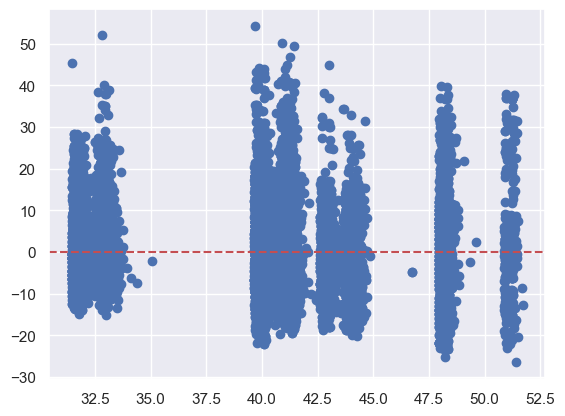

In [32]:
predicted_results = linear_results.predict(df_train)
residuals = df_train["age"] - predicted_results
plt.scatter(x = predicted_results, y = residuals)
plt.axhline(y = 0, color = 'r', linestyle = '--')
plt.show()

#### **Interpreting Linear Regression Conditions:**

**Linearity Assumption:** Looking at the Fitted vs Residual plot, because the fitted values are in groups or clusters rather than in a random scatter around the red line, the Linearity Assumption does not seem to be satisfied.

**Normality:** The QQ Plot above shows how the line it forms is not truly linear with a slight curve. If I scaled the x-axis to equal scale to the y-axis, the curve of the line would be more identifiable. Therefore, the 'Normality Assumption' is not satisfied.

**Equal Variance:** Looking at the Fitted vs Residual plot, all of the residuals for the fitted values seem to be evenly spread out, and this spead never changes, therefore Equal Varience is satisfied here.

**No Multicollinearity:** Since more than 1 quantitative predictor was not used in the linear model to predict the age of Portugese Bank clients, the model does not have any multicollinearity. Therefore, the 'No Multicollinearity' assumption is satisfied.

### **Evaluating Model Performance:**

**R-Squared** = 0.21895760055558666

In [17]:
linear_results.rsquared

np.float64(0.21895760055558655)

Only 21.90% of the variability in the variable "age" is explained by the linear model (its linear relationship with "housing", "education", and "marital", and "duration") in the training data. This is a low percentage, indicating that the overall linear model is potentially weak.

**RMSE** = 9.09125073698656

In [18]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(df_train["age"], linear_results.predict(df_train))

9.09125073698656

Roughly, the typical distance a client's observed age falls from their predicted age is about 9.09 years. This high value indicates that the typical size of the linear model's error is considerably big, implying that the linear model may not be a good fit for the training data.

## 3. Logistic Regression Analytical Tasks

### **Research Question 2:**

How does the outcome of the previous marketing campaign (poutcome) with a client, their job (grouped_jobs), and the number of times the client has been contacted before this campaign (previous) relate to the log-odds of the success level of whether the client has subscribed to the bank's term deposit (subscribed) during the curent campaign in the sample training data? How does a classifier built on this model perform on new data?

### **Fitting Logistic Regression Model to Training Data:**

In [19]:
logistic_results = smf.logit("subscribed ~ poutcome + grouped_jobs + previous", data = df_train).fit()
logistic_results.summary()

Optimization terminated successfully.
         Current function value: 0.340340
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             subscribed   No. Observations:                24390
Model:                          Logit   Df Residuals:                    24384
Method:                           MLE   Df Model:                            5
Date:                Fri, 01 May 2026   Pseudo R-squ.:                  0.1017
Time:                        17:00:33   Log-Likelihood:                -8300.9
converged:                       True   LL-Null:                       -9240.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -2.5278      0.099    -25.541      0.000      -2.722      -2.334
poutcome[T.nonexistent]          0.0917      0.099      0.928      0.353      -0.102       0.285
poutcome[T.success]              2.2191      0.089     25.002      0.000       2.045       2.393
grouped_jobs[T.non-working]      0.9462      0.065     14.652      0.000       0.820       1.073
grouped_jobs[T.white-collar]     0.2935      0.044      6.618      0.000       0.207       0.380
previous                         0.4007      0.063      6.311      0.000       0.276       0.525
================================================================================================
"""

#### *Characteristics Associated with Higher Succcess Probability*

In [33]:
import numpy as np
def log_odds_to_prob(log_odds):
    return 1 / (1 + np.exp(-log_odds))
print("Calculated Probability from predictors:")
print("poutcome[T.nonexistent]:",log_odds_to_prob(0.0917))
print("poutcome[T.success]:",log_odds_to_prob(2.2191))
print("grouped_jobs[T.non-working]:",log_odds_to_prob(0.9462))
print("poutcome[T.white-collar]:",log_odds_to_prob(0.2935))
print("previous:",log_odds_to_prob(0.4007))

Calculated Probability from predictors:
poutcome[T.nonexistent]: 0.5229089490133588
poutcome[T.success]: 0.901951633093917
grouped_jobs[T.non-working]: 0.7203503255888212
poutcome[T.white-collar]: 0.5728527741439899
previous: 0.5988558310101294


Looking at the probablities of all of the individual predictors, the predictors that lead to the highest success probability of a client subscribing to the term deposit would be "poutcome[T.success]:" and grouped_jobs[T.non-working]".

#### *Model Strength*

In [21]:
df_train["p_hat"] = logistic_results.predict(df_train)

Area Under the Curve (AUC) of the Logistic Model = 0.6645966636724776

In [22]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
auc = roc_auc_score(y_true = df_train["subscribed"], y_score = df_train["p_hat"])
auc

0.6645966636724776

$R^2_\text{Pseudo}$ of the Logistic Model = 0.10167240639638397

In [23]:
logistic_results.prsquared

np.float64(0.10167240639638397)

The AUC measures how well the model distinguishes between subscribers and non-subscribers at all possible predictive probability thresholds. An AUC of 0.664 is moderately weak and demonstrates that the model is not good at distinguishing between those who are and are not subscribed. The Pseudo R-squared, which measures the strength of the logistic model, aligns with this as a Pseudo R-squared of 0.10167 is not between 0.2 and 0.4, therefore the model is not a strong fit, meaning the predictor values are ineffective at predicting the log-odds of a client being subscribed.

### **Building & Evaluating Classifier:**

After testing different values with the table below to optimize the classifier's accuracy rate, I will select **0.2 as the predictive probability threshold** for creating a classifier.

In [24]:
df_train["y_hat"] = 1 * (df_train["p_hat"] > 0.2)

In [25]:
pd.crosstab(df_train["subscribed"], df_train["y_hat"])

y_hat,0,1
subscribed,,
0,20715,600
1,2342,733


True Negatives (TN) = 20,715

False Negatives (FN) = 600

False Positives (FP) = 2,342

True Positives (TP) = 733

In [26]:
TN = 20715
FN = 600
FP = 2342
TP = 733

*Accuracy Rate of the Classifier:* = 4.8656987295825775

In [37]:
accuracy_rate = (TP + TN)/(TP + FN + FP + TN)
accuracy_rate

0.8793767937679376

*Sensitivity Rate (True Positive Rate) of the Classifier:* = 0.5498874718679669

In [38]:
sensitivity_rate = (TP)/(TP + FN)
sensitivity_rate

0.5498874718679669

*Specificity Rate (True Negative Rate) of the Classifier:* = 0.8984256408032267

In [40]:
specificity_rate = (TN)/(TN + FP)
specificity_rate

0.8984256408032267

*Type of Error to Minimize:*

Since the Portuguese bank wouldn't want to waste time and resources on targeting clients who wouldn't subscribe to their term deposit, the type of error I would like to minimize would be the **false positive rate.** False positive error, in this case, would mean that the bank predicted that a client would subscribe to the term deposit when they wouldn't in reality, leading them to waste time by focusing on the wrong audience for their marketing campaign.

*Concluding on Performance of Classifier:*

In the classifier, the **false positive rate** is: 

1 - Sensitivity Rate = 1 - 0.8984256408032267 = **0.10157435919677327**

Since the classifier's false positive rate is at a low percentage of 10.16%, **the current classifier's performance seems strong and preferable.** This is because the bank aims to minimize the probability of them marketing their term deposits to clients who won't buy them.

## 4. Conclusion

**Summarization**

In this project, I used both linear regression and logistic regression to better understand relationships within the dataset and to make predictions. The linear regression model enabled me to quantify how multiple explanatory variables were associated with a continuous response variable and evaluate how well the model explained variability in the data. The logistic regression model was used to predict a binary outcome and to build a classifier. Because the model has a good predictive ability, and the classifier's performance, evaluated by the particularly low false positive rate of about 10.16%, indicates that it is well-suited for practical use in its current form. Overall, these analyses highlight the usefulness of regression-based modeling in real-world prediction tasks. 

**Limitations**

There are several potential limitations to this analysis that should be considered. First, the model performance may be limited by the quality and structure of the dataset, including potential missing variables or unaccounted confounding factors. Additionally, assumptions of linear regression (such as linearity and equal variance) may not be fully satisfied, which could impact the validity of the results. For the logistic regression model, the relatively low false positive rate might still be higher than what the Portugese Bank would like, in order to capture more subscribers. Furthermore, the choice of having a predictive probability threshold of 0.2 for classification may not be optimal and could lead to a higher misclassification rate, significantly affect performance metrics. These limitations suggest that conclusions drawn from this analysis should be interpreted with caution. 

**Future Work**

Future work could focus on improving model performance and expanding the analysis. For example, additional explanatory variables could be incorporated to better capture the underlying relationships in the data. Alternative modeling approaches, such as decision trees, random forests, or other machine learning methods, could be explored to improve classification accuracy and reduce the false positive rate. Additionally, tuning the classification threshold or using techniques such as cross-validation could help optimize model performance. Finally, further analysis could investigate feature importance and interaction effects to provide deeper insights into the factors influencing the response variables. 